### Summarization MiddleWare
Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:
- Long-running conversations that exceed context windows.
- Multi-turn dialogues with extensive history.
- Applications where preserving full conversation context matters.

You need to inform agent when to start summarization, assume started summarization at 3 messages. Message counts with AI+Human, and also provided checkpointer which is where to store the summrized details and the keep arg defines how many messages do we need to store as part of summary.

c:\Users\sumsaras\Documents\PersonalWorkspace\AI_Learning\RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


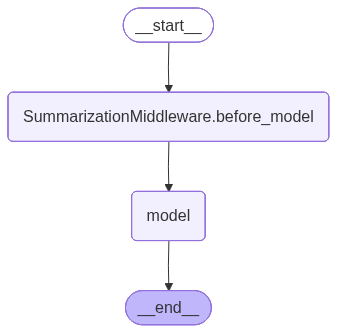

In [1]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage, SystemMessage, AIMessage

llm_model = init_chat_model(model='openai/gpt-oss-120b',temperature=0.4, model_provider='groq')
agent = create_agent(
    model = llm_model,
    checkpointer = InMemorySaver(),
    middleware = [
        SummarizationMiddleware(
            model= llm_model,
            trigger=("messages", 3),
            keep=("messages", 2)
        )
    ]
)
agent

In [2]:
config = {"configurable":{"thread_id":"test-5"}}
messages = [
    "What companies has Elon Musk founded or led?",
    "How did Elon Musk contribute to the success of Tesla?",
    "What is SpaceX, and why is it important for space exploration?",
]

for question in messages:
    print(f"question: {question}")
    result = agent.invoke({"messages":question}, config)
    print(result)

question: What companies has Elon Musk founded or led?
{'messages': [HumanMessage(content='What companies has Elon Musk founded or led?', additional_kwargs={}, response_metadata={}, id='7962d0eb-917d-4e8f-80ef-8d370f393c9e'), AIMessage(content='Elon\u202fMusk has been a founder, co‑founder, or chief executive of a number of high‑profile technology and transportation companies. Below is a concise overview of the most notable ones, organized by the role he played and the time period.\n\n| Company | Year Founded / Acquired | Musk’s Role | Brief Description |\n|---------|------------------------|-------------|-------------------|\n| **Zip2 Corporation** | 1996 (co‑founded) | Co‑founder & CEO | One of the first online city‑guide services, providing business directories and maps to newspapers. Sold to Compaq for ≈\u202f$307\u202fM in 1999. |\n| **X.com / PayPal** | 1999 (X.com founded) | Founder & CEO (later Chairman) | An online payment and financial services company. X.com was renamed PayP

### Token Size

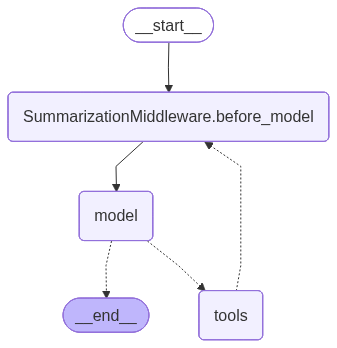

In [3]:
from langchain.tools import tool

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi"""

agent = create_agent(
    model= llm_model,
    tools= [search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model= llm_model,
            trigger=("tokens",500),
            keep=("tokens", 200)
        )
    ]
)
agent

In [4]:
config = {"configurable":{"thread_id":"test-2"}}

cities = ["Delhi", "Barelliey", "Jodhpur", "Jaislmer"]
for city in cities:
    print(f"city : {city}")
    response = agent.invoke({"messages":f"find hotels in {city}"}, config)
    print(response)

city : Delhi
{'messages': [HumanMessage(content='find hotels in Delhi', additional_kwargs={}, response_metadata={}, id='47e29185-2d13-4f11-9dc3-7f60a5ca6ae5'), AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants to find hotels in Delhi. We have a function search_hotels(city). We should call it.', 'tool_calls': [{'id': 'fc_cc8991a3-8bd6-4232-8986-49fd12216ead', 'function': {'arguments': '{"city":"Delhi"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 129, 'total_tokens': 180, 'completion_time': 0.111149418, 'completion_tokens_details': {'reasoning_tokens': 23}, 'prompt_time': 0.025519991, 'prompt_tokens_details': None, 'queue_time': 0.051055129, 'total_time': 0.136669409}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_ce855234b5', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dd802-e80d-76f3-955d

### Human in the loop middleware

Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:
- High-stakes operations requiring human approval (e.g. database writes, financial transactions).
- Compliance workflows where human oversight is mandatory.
- Long-running conversations where human feedback guides the agent.

c:\Users\sumsaras\Documents\PersonalWorkspace\AI_Learning\RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


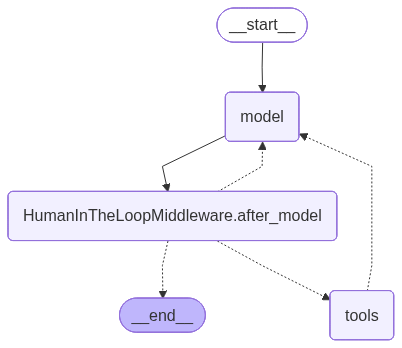

In [1]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage
from langchain.tools import tool

llm_model = init_chat_model(model='openai/gpt-oss-120b',temperature=0.4, model_provider='groq')

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

human_loop_agent = create_agent(
    model=llm_model,
    tools=[read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve", "edit", "reject"]
                },
                read_email_tool:False
            }
        )
    ]
)
human_loop_agent

In [ ]:
config = {"configurable":{"thread_id":"task-1"}}
result = human_loop_agent.invoke({"messages":[HumanMessage(content="Read message from the inbox, which sent by sumit@gmail.com")]}, config=config)
result

{'messages': [HumanMessage(content='Read message from the inbox, which sent by sumit@gmail.com', additional_kwargs={}, response_metadata={}, id='7d2a218f-9a60-475e-b147-170afe47123b'),
  AIMessage(content='I’m happy to pull up that email for you. Could you please provide the\u202femail\u202fID (or any other identifier) of the message from\u202fsumit@gmail.com\u202fthat you’d like to read?', additional_kwargs={'reasoning_content': "The user wants to read a message from the inbox, sent by sumit@gmail.com. We need to read email by ID, but we don't know the ID. We might need to search? There's no function to search. We only have read_email_tool which takes email_id. We don't have a function to list emails. Possibly we need to ask for clarification? But we could attempt to read email with a guessed ID? Better to ask for the email ID. So respond asking for email ID."}, response_metadata={'token_usage': {'completion_tokens': 153, 'prompt_tokens': 169, 'total_tokens': 322, 'completion_time': 0

In [ ]:
result = human_loop_agent.invoke({"messages":[HumanMessage(content="Read email from the email id sumit@gmail.com")]}, config=config)
result

{'messages': [HumanMessage(content='Read message from the inbox, which sent by sumit@gmail.com', additional_kwargs={}, response_metadata={}, id='7d2a218f-9a60-475e-b147-170afe47123b'),
  AIMessage(content='I’m happy to pull up that email for you. Could you please provide the\u202femail\u202fID (or any other identifier) of the message from\u202fsumit@gmail.com\u202fthat you’d like to read?', additional_kwargs={'reasoning_content': "The user wants to read a message from the inbox, sent by sumit@gmail.com. We need to read email by ID, but we don't know the ID. We might need to search? There's no function to search. We only have read_email_tool which takes email_id. We don't have a function to list emails. Possibly we need to ask for clarification? But we could attempt to read email with a guessed ID? Better to ask for the email ID. So respond asking for email ID."}, response_metadata={'token_usage': {'completion_tokens': 153, 'prompt_tokens': 169, 'total_tokens': 322, 'completion_time': 0

In [9]:
result = human_loop_agent.invoke({"messages":[HumanMessage(content="Read email from sumit@gmail.com")]}, config=config)
result

{'messages': [HumanMessage(content='Read message from the inbox, which sent by sumit@gmail.com', additional_kwargs={}, response_metadata={}, id='7d2a218f-9a60-475e-b147-170afe47123b'),
  AIMessage(content='I’m happy to pull up that email for you. Could you please provide the\u202femail\u202fID (or any other identifier) of the message from\u202fsumit@gmail.com\u202fthat you’d like to read?', additional_kwargs={'reasoning_content': "The user wants to read a message from the inbox, sent by sumit@gmail.com. We need to read email by ID, but we don't know the ID. We might need to search? There's no function to search. We only have read_email_tool which takes email_id. We don't have a function to list emails. Possibly we need to ask for clarification? But we could attempt to read email with a guessed ID? Better to ask for the email ID. So respond asking for email ID."}, response_metadata={'token_usage': {'completion_tokens': 153, 'prompt_tokens': 169, 'total_tokens': 322, 'completion_time': 0

In [2]:
config = {"configurable":{"thread_id":"task-4"}}
result = human_loop_agent.invoke({"messages":[HumanMessage(content="Send email to sumit@gmail.com with subject Buy a udemy course, You should buy this attached course")]}, config = config)
result

{'messages': [HumanMessage(content='Send email to sumit@gmail.com with subject Buy a udemy course, You should buy this attached course', additional_kwargs={}, response_metadata={}, id='f56a51be-e988-4eb1-ba4c-7fc19ac31c47'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to send email. Use send_email_tool. Need body: "You should buy this attached course". Subject: "Buy a udemy course". Recipient: sumit@gmail.com. Let\'s call function.', 'tool_calls': [{'id': 'fc_19663fa6-f99b-4dc7-99f9-1d90e7a1a1c9', 'function': {'arguments': '{"body":"You should buy this attached course","recipient":"sumit@gmail.com","subject":"Buy a udemy course"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 97, 'prompt_tokens': 177, 'total_tokens': 274, 'completion_time': 0.211761051, 'completion_tokens_details': {'reasoning_tokens': 43}, 'prompt_time': 0.007640659, 'prompt_tokens_details': None, 'queue_time': 0.058949881, 'tot

In [3]:
from langgraph.types import Command

if "__interrupt__" in result:
    print("Paused! Approving")
    result = human_loop_agent.invoke(
        Command(
            resume={
                "decisions":[
                    {"type":"approve"}
                ]
            }
        ),
        config=config
    )

result


Paused! Approving


{'messages': [HumanMessage(content='Send email to sumit@gmail.com with subject Buy a udemy course, You should buy this attached course', additional_kwargs={}, response_metadata={}, id='f56a51be-e988-4eb1-ba4c-7fc19ac31c47'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to send email. Use send_email_tool. Need body: "You should buy this attached course". Subject: "Buy a udemy course". Recipient: sumit@gmail.com. Let\'s call function.', 'tool_calls': [{'id': 'fc_19663fa6-f99b-4dc7-99f9-1d90e7a1a1c9', 'function': {'arguments': '{"body":"You should buy this attached course","recipient":"sumit@gmail.com","subject":"Buy a udemy course"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 97, 'prompt_tokens': 177, 'total_tokens': 274, 'completion_time': 0.211761051, 'completion_tokens_details': {'reasoning_tokens': 43}, 'prompt_time': 0.007640659, 'prompt_tokens_details': None, 'queue_time': 0.058949881, 'tot

### Reject

In [19]:
config = {"configurable":{"thread_id":"task-1"}}
result = human_loop_agent.invoke({"messages":[HumanMessage(content="Send email to sumit@gmail.com with subject Buy a udemy course, You should buy this attached course")]}, config = config)
result

{'messages': [HumanMessage(content='Send email to sumit@gmail.com with subject Buy a udemy course, You should buy this attached course', additional_kwargs={}, response_metadata={}, id='9d3bd188-a4f2-4b34-9b45-5f2e6a150ebd'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user wants to send an email to sumit@gmail.com with subject "Buy a udemy course" and body "You should buy this attached course". There\'s no attachment functionality. We\'ll just send email with given body. Use send_email_tool.', 'tool_calls': [{'id': 'fc_f441142d-2813-4c44-ba8f-8be71ebd2b6f', 'function': {'arguments': '{"body":"You should buy this attached course","recipient":"sumit@gmail.com","subject":"Buy a udemy course"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 104, 'prompt_tokens': 177, 'total_tokens': 281, 'completion_time': 0.229347876, 'completion_tokens_details': {'reasoning_tokens': 50}, 'prompt_time': 0.007601301, 'pro

In [ ]:
if "__interrupt__" in result:
    print("Asking for decision, paused.....")
    result = human_loop_agent.invoke(
        Command(
            resume={
                "decisions":[
                    {"type":"reject"}
                ]
            }
        ),
        config
    )
result

{'messages': [HumanMessage(content='Send email to sumit@gmail.com with subject Buy a udemy course, You should buy this attached course', additional_kwargs={}, response_metadata={}, id='9d3bd188-a4f2-4b34-9b45-5f2e6a150ebd'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user wants to send an email to sumit@gmail.com with subject "Buy a udemy course" and body "You should buy this attached course". There\'s no attachment functionality. We\'ll just send email with given body. Use send_email_tool.', 'tool_calls': [{'id': 'fc_f441142d-2813-4c44-ba8f-8be71ebd2b6f', 'function': {'arguments': '{"body":"You should buy this attached course","recipient":"sumit@gmail.com","subject":"Buy a udemy course"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 104, 'prompt_tokens': 177, 'total_tokens': 281, 'completion_time': 0.229347876, 'completion_tokens_details': {'reasoning_tokens': 50}, 'prompt_time': 0.007601301, 'pro

### Edit

In [42]:
config = {"configurable":{"thread_id":"task-8"}}
result = human_loop_agent.invoke({"messages":[HumanMessage(content="Send email to wrong@gmail.com with subject Buy a udemy course, You should buy this attached course")]}, config = config)
result

{'messages': [HumanMessage(content='Send email to wrong@gmail.com with subject Buy a udemy course, You should buy this attached course', additional_kwargs={}, response_metadata={}, id='f31ba392-caa6-4cee-8f31-a7e1ae6011dd'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to send email. Use send_email_tool. Need body: "You should buy this attached course". Subject: "Buy a udemy course". Recipient: "wrong@gmail.com".', 'tool_calls': [{'id': 'fc_1a702ecf-b96e-417e-9325-a51b5131fc0f', 'function': {'arguments': '{"body":"You should buy this attached course","recipient":"wrong@gmail.com","subject":"Buy a udemy course"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 92, 'prompt_tokens': 176, 'total_tokens': 268, 'completion_time': 0.198083235, 'completion_tokens_details': {'reasoning_tokens': 39}, 'prompt_time': 0.006650965, 'prompt_tokens_details': None, 'queue_time': 0.050734269, 'total_time': 0.2047342}

In [44]:
if "__interrupt__" in result:
    print("Paused, to ask for decission....")
    result = human_loop_agent.invoke(
        Command(
            resume={
                "decisions":[
                    {
                        "type":"edit",
                        "edited_action":{
                            "name": "send_email_tool",
                            "args":{
                                "recipient":"correct@gmail.com",
                                "subject":"Buy a udemy course",
                                "body":"You should buy this attached course"
                            }
                        }
                    }
                ]
            }
        ), config
    )
result

Paused, to ask for decission....


{'messages': [HumanMessage(content='Send email to wrong@gmail.com with subject Buy a udemy course, You should buy this attached course', additional_kwargs={}, response_metadata={}, id='f31ba392-caa6-4cee-8f31-a7e1ae6011dd'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to send email. Use send_email_tool. Need body: "You should buy this attached course". Subject: "Buy a udemy course". Recipient: "wrong@gmail.com".', 'tool_calls': [{'id': 'fc_1a702ecf-b96e-417e-9325-a51b5131fc0f', 'function': {'arguments': '{"body":"You should buy this attached course","recipient":"wrong@gmail.com","subject":"Buy a udemy course"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 92, 'prompt_tokens': 176, 'total_tokens': 268, 'completion_time': 0.198083235, 'completion_tokens_details': {'reasoning_tokens': 39}, 'prompt_time': 0.006650965, 'prompt_tokens_details': None, 'queue_time': 0.050734269, 'total_time': 0.2047342}